# Student information
*   **Student ID:** 20520278
*   **Full name:** Pham Hoang Phuc



# Get libraries

## Install

In [ ]:
%pip install xgboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Import

In [ ]:
import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from xgboost import XGBClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (KFold,
                                     train_test_split,
                                     RandomizedSearchCV)

from sklearn.metrics import (f1_score,
                             recall_score,
                             accuracy_score,
                             precision_score,
                             confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay,
                             precision_recall_fscore_support)

# Get dataset

## Make dataframe

In [ ]:
# Get file link ID and download dataset in notebook
output = 'cleaned_credit_score.csv'
id = '1r9PVVOkMXsNhVzq0QsGRT4J6UwPy0Z9-'

In [ ]:
gdown.download(id=id, output=output) # Download data

Downloading...
From: https://drive.google.com/uc?id=1r9PVVOkMXsNhVzq0QsGRT4J6UwPy0Z9-
To: /content/cleaned_credit_score.csv
100%|██████████| 20.1M/20.1M [00:00<00:00, 77.2MB/s]


'cleaned_credit_score.csv'

In [ ]:
# Read dataset and make dataframe
df = pd.read_csv(output)

In [ ]:
# Print 5 first lines
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,credit-builder loan,home equity loan,student loan,payday loan,personal loan,mortgage loan,debt consolidation loan,not specified,No Data,Credit_Score
0,1,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,1,0,0,1,0,0,0,0,0
1,2,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1.0,...,1,1,0,0,1,0,0,0,0,0
2,3,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,1,0,0,1,0,0,0,0,0
3,4,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,...,1,1,0,0,1,0,0,0,0,0
4,5,23.0,12,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,1,1,0,0,1,0,0,0,0,0


## Get input features and output

In [ ]:
# Split dataset to input features and output
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [ ]:
# Print shape
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100000, 33)
y shape: (100000,)


# Training and testing

In [ ]:
# Train test split with test size is 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Print training shape
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (80000, 33)
y_train shape: (80000,)


In [ ]:
# Print testing shape
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 33)
y_test shape: (20000,)


In [ ]:
# Make the default XGB Model, then training and testing
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      3527
           1       0.77      0.75      0.76      5874
           2       0.80      0.80      0.80     10599

    accuracy                           0.78     20000
   macro avg       0.76      0.77      0.76     20000
weighted avg       0.78      0.78      0.78     20000



In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Average macro F1 : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred, average='macro'):.3f}")

Accuracy : 0.776
Average macro F1 : 0.764
Average macro Recall : 0.767
Average macro Precision : 0.761


# Fine tuning

In [ ]:
# Get parameters need to fine tuning
params = {
    # The "n_estimators" in XGBoost signifies the number of boosting iterations.
    "n_estimators": range(100, 500, 50),

    # Learning rate shrinks the weights to make the boosting process more conservative
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1],

    # Maximum depth of the tree, increasing it increases the model complexity.
    "max_depth": range(3, 21, 3),

    # Gamma specifies the minimum loss reduction required to make a split.
    "gamma": [i / 10.0 for i in range(0, 5)],

    # Percentage of columns to be randomly samples for each tree.
    "colsample_bytree": [i / 10.0 for i in range(3, 10)],

    # reg_alpha provides l1 regularization to the weight, higher values result in more conservative models
    "reg_alpha": [1e-5, 1e-2, 0.1, 1, 10, 100],

    # reg_lambda provides l2 regularization to the weight, higher values result in more conservative models
    "reg_lambda": [1e-5, 1e-2, 0.1, 1, 10, 100]
}

# Create and fit fine tuning Model
rs = RandomizedSearchCV(XGBClassifier(),
                        params,
                        n_iter=50,
                        verbose=3,
                        random_state=42)
rs.fit(X_train, y_train)

# Print best score and best parameters
# when random search with above parameters
print('Best score:', rs.best_score_)
print('Best parameters:', rs.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.723 total time=  34.0s
[CV 2/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.731 total time=  35.8s
[CV 3/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.719 total time=  41.0s
[CV 4/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.727 total time=  42.8s
[CV 5/5] END colsample_bytree=0.5, gamma=0.4, learning_rate=0.0001, max_depth=12, n_estimators=250, reg_alpha=10, reg_lambda=0.1;, score=0.718 total time=  39.1s
[CV 1/5] END colsample_bytree=0.6, gamma=0.1, learning_rate=1, max_depth=18, n_estimators=450, reg_alpha=1, reg_lambda=100;, sco

In [ ]:
# Save results
cv_results = pd.DataFrame(rs.cv_results_)
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)
cv_results.to_csv("RandomSearch_CV_XGBoost.csv")

In [ ]:
# Load results
cv_results = pd.read_csv("RandomSearch_CV_XGBoost.csv")

In [ ]:
cv_results.sort_values(by=['rank_test_score']).head(5)[['param_reg_lambda',
                                                        'param_reg_alpha',
                                                        'param_n_estimators',
                                                        'param_max_depth',
                                                        'param_learning_rate',
                                                        'param_gamma',
                                                        'param_colsample_bytree',
                                                        'mean_test_score']]

,param_reg_lambda,param_reg_alpha,param_n_estimators,param_max_depth,param_learning_rate,param_gamma,param_colsample_bytree,mean_test_score
0,0.00001,0.00001,450,15,0.1,0.2,0.5,0.826763
1,0.00001,0.10000,350,18,0.1,0.4,0.7,0.826225
2,0.00001,1.00000,450,18,0.1,0.4,0.4,0.825613
3,0.10000,0.10000,350,15,0.1,0.4,0.3,0.825050
4,0.01000,0.10000,100,15,0.1,0.2,0.8,0.821250


# Evaluation

## Training and testing

In [ ]:
# Training and testing with best parameters XGB Model
xgbf = XGBClassifier(reg_lambda=1e-05,
                     reg_alpha=1e-05,
                     n_estimators=450,
                     max_depth=15,
                     learning_rate=0.1,
                     gamma=0.2,
                     colsample_bytree=0.5,
                     n_jobs=-1)
xgbf.fit(X_train, y_train)

# Classification report and score of training, testing
y_pred = xgbf.predict(X_test)

print(" " * 23 + "RESULT" + " " * 24)

print("Accuracy test: ", xgbf.score(X_test, y_test))
print("=" * 53)

print(classification_report(y_test, y_pred))

                       RESULT                        
Accuracy test:  0.8375
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3527
           1       0.82      0.86      0.84      5874
           2       0.86      0.84      0.85     10599

    accuracy                           0.84     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.84      0.84      0.84     20000



In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Average macro F1 : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred, average='macro'):.3f}")

Accuracy : 0.838
Average macro F1 : 0.831
Average macro Recall : 0.833
Average macro Precision : 0.829


## K-Fold validation

In [ ]:
# Plot accuracy, macro average precision, recall and f1 score
target_names = ['Good', 'Poor', 'Standard']

kf = KFold(n_splits=10, shuffle=True)
metrics = []

acc = []
f1_macro = []
recall_macro = []
precision_macro = []

confusion_matrices = np.zeros((3,3))

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    xgbf.fit(X[train_index], y[train_index])
    y_pred = xgbf.predict(X[test_index])
    print(classification_report(y[test_index], y_pred, target_names=target_names))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(xgbf.score(X[test_index], y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))
    confusion_matrices += confusion_matrix(y[test_index], y_pred)

print("Mean accuray:", np.mean(acc))

Fold 0:
              precision    recall  f1-score   support

        Good       0.81      0.82      0.81      1784
        Poor       0.82      0.88      0.85      2913
    Standard       0.87      0.83      0.85      5303

    accuracy                           0.84     10000
   macro avg       0.83      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000


Fold 1:
              precision    recall  f1-score   support

        Good       0.81      0.82      0.81      1714
        Poor       0.83      0.87      0.85      2963
    Standard       0.87      0.84      0.85      5323

    accuracy                           0.85     10000
   macro avg       0.83      0.84      0.84     10000
weighted avg       0.85      0.85      0.85     10000


Fold 2:
              precision    recall  f1-score   support

        Good       0.82      0.82      0.82      1803
        Poor       0.82      0.87      0.84      2859
    Standard       0.87      0.84      0.85      

## Visualize result

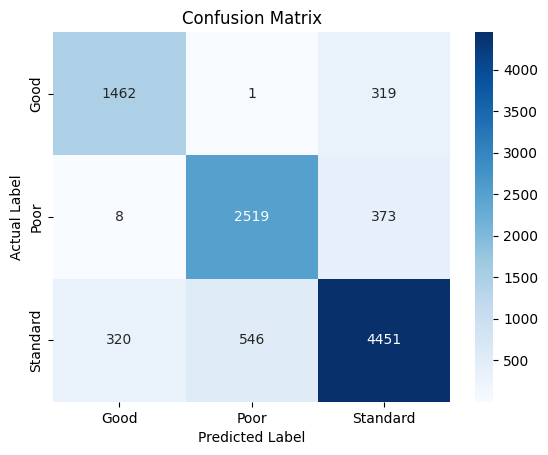

In [ ]:
# Create labels for the confusion matrix
labels = ['Good', 'Poor', 'Standard']

# Create a heatmap using seaborn
sns.heatmap(np.round(confusion_matrices / 10).astype(np.int64), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set plot title and axes labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Display the plot
plt.show()

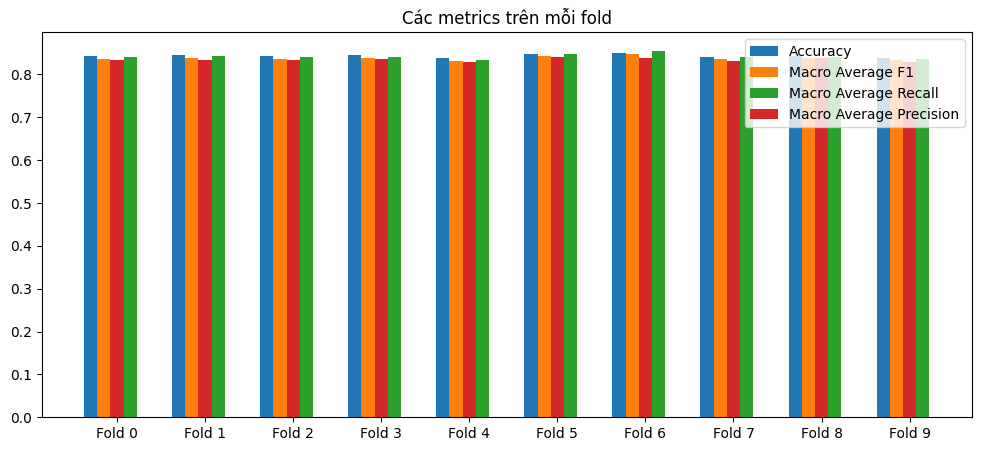

In [ ]:
plt.figure(figsize=(12,5))
X_ticks = ["Fold " + str(i) for i in range(10)]
X_axis = np.arange(len(X_ticks))
plt.bar(X_axis - 0.3, acc, 0.15, label="Accuracy", tick_label=X_ticks)
plt.bar(X_axis - 0.15, f1_macro, 0.15, label="Macro Average F1", tick_label=X_ticks)
plt.bar(X_axis + 0.15, recall_macro, 0.15, label="Macro Average Recall", tick_label=X_ticks)
plt.bar(X_axis, precision_macro, 0.15, label="Macro Average Precision", tick_label=X_ticks)
plt.title("Các metrics trên mỗi fold")
plt.legend()
plt.show()

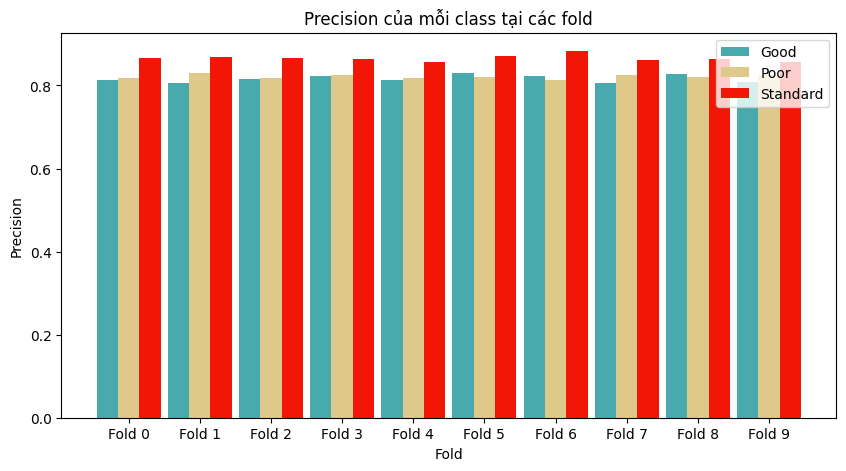

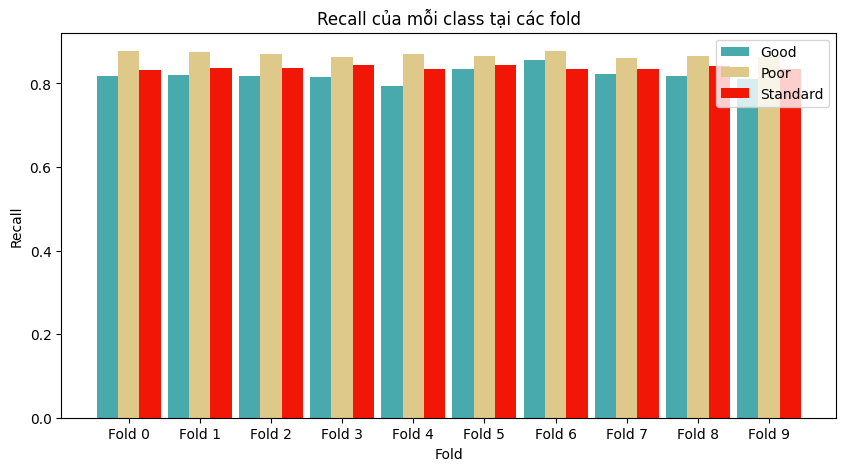

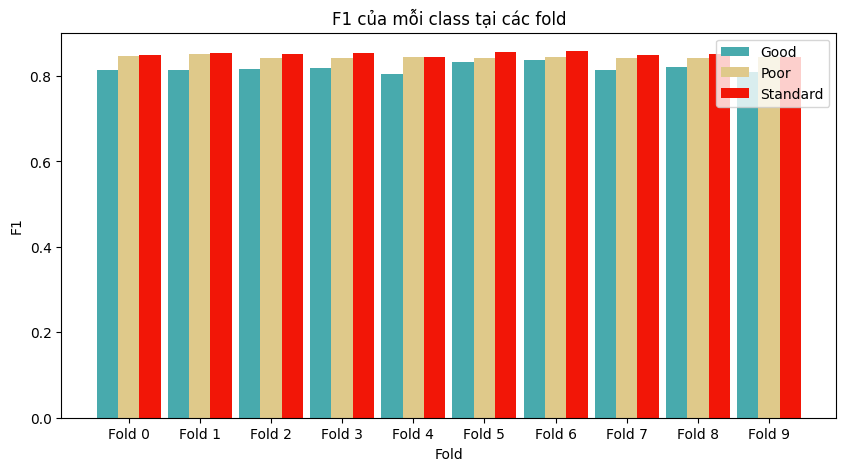

In [ ]:
# Plot precision, recall and f1 score of each class in each fold
metrics_dict = {
    "Precision": [],
    "Recall" : [],
    "F1": []
}

for i in range(10):
  metrics_dict["Precision"].append(metrics[i][0])
  metrics_dict["Recall"].append(metrics[i][1])
  metrics_dict["F1"].append(metrics[i][2])

metrics_dict["Precision"] = np.vstack(metrics_dict["Precision"])
metrics_dict["Recall"] = np.vstack(metrics_dict["Recall"])
metrics_dict["F1"] = np.vstack(metrics_dict["F1"])

for metric, values in metrics_dict.items():
  plt.figure(figsize=(10,5))
  plt.bar(X_axis - 0.2, values[:, 0], 0.3,
          label="Good", color="#48AAAD")
  plt.bar(X_axis + 0.1, values[:, 1], 0.3,
          label="Poor", tick_label=X_ticks, color="#DFC98A")
  plt.bar(X_axis + 0.4, values[:, 2], 0.3,
          label="Standard", color="#f21607")

  plt.title(f"{metric} của mỗi class tại các fold")
  plt.xlabel("Fold")
  plt.ylabel(f"{metric}")

  plt.legend()
  plt.show()

In [ ]:
print(f"Average macro F1 : {np.mean(f1_macro):.3f}")
print(f"Average macro Recall : {np.mean(recall_macro):.3f}")
print(f"Average macro Precision : {np.mean(precision_macro):.3f}")

Average macro F1 : 0.838
Average macro Recall : 0.842
Average macro Precision : 0.835


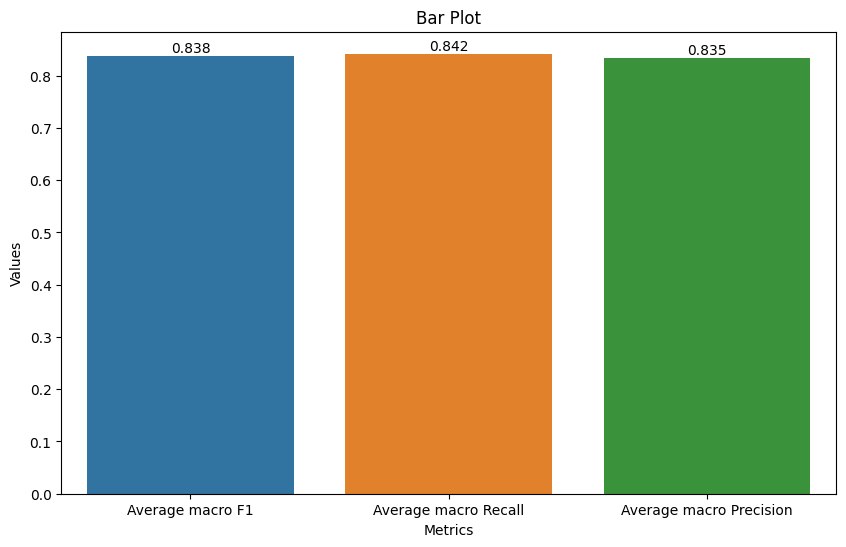

In [ ]:
# Sample data
categories = ['Average macro F1', 'Average macro Recall', 'Average macro Precision']
values = [np.mean(f1_macro), np.mean(recall_macro), np.mean(precision_macro)]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=categories, y=values)

# Add numbers on top of the bars
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center', va='bottom')

# Set plot title and axes labels
plt.title('Bar Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Display the plot
plt.show()